# LLM-SRBench: A New Benchmark for Scientific Equation Discovery with Large Language Models

**Paper:** Shojaee, P., Nguyen, N.-H., Meidani, K., Barati Farimani, A., Doan, K. D., & Reddy, C. K. (2025). *LLM-SRBench: A New Benchmark for Scientific Equation Discovery with Large Language Models.* Proceedings of the 42nd International Conference on Machine Learning (ICML).

**Carpeta origen:** `Papers/04_LLMs_y_Busqueda_Evolutiva/Shojaee_etal_2025_LLM-SRBench.pdf`

## Que se reproduce en este cuaderno

Los LLM tienen un problema de evaluacion particular en descubrimiento de ecuaciones: han visto millones de textos que mencionan "la ley de Coulomb es $q_1q_2/r^2$", asi que un benchmark que use formulas famosas con sus nombres de variable habituales puede estar midiendo **memorizacion** del texto de entrenamiento, no descubrimiento genuino a partir de datos. La idea central de LLM-SRBench es **reformular** las ecuaciones conocidas (renombrando variables, reescribiendolas algebraicamente) para que el reconocimiento textual directo deje de funcionar, obligando a una busqueda real guiada por los datos.

Reproducimos este fenomeno de forma directa y controlada, comparando dos "solucionadores" sobre **los mismos datos numericos exactos** de la ley de Coulomb ($F=q_1q_2/r^2$), presentados de dos formas:

1. **Version "de libro de texto":** variables llamadas `q1`, `q2`, `r` (los nombres habituales en cualquier libro de fisica).
2. **Version renombrada:** las mismas variables, exactamente los mismos valores numericos, llamadas `p`, `s`, `w`.

Un **solucionador de memorizacion** (una biblioteca que reconoce formulas por los nombres de sus variables, imitando el atajo que un LLM podria tomar al reconocer un patron textual familiar) funciona perfectamente en la version 1 y **fracasa por completo** en la version 2, pese a tratarse exactamente de los mismos datos. Un **solucionador de descubrimiento genuino** (programacion genetica, que solo ve los valores numericos y nunca los nombres) resuelve ambas versiones **identicamente** -- exactamente la distincion que LLM-SRBench esta disenado para medir.

## Repositorio publico

El paper no publica un repositorio de codigo bajo un nombre propio distinto del proyecto `LLM-SR` de los mismos autores (ya clonado en `codigo/LLM-SR` y usado en el cuaderno `LLM-SR - Ecuaciones como Programas...` de esta coleccion). Aqui no reimplementamos LLMs reales (ver honestidad abajo); construimos un solucionador de memorizacion deliberadamente simplista (una biblioteca de patrones por nombre de variable) como sustituto ilustrativo del "atajo de memorizacion" que el paper busca detectar en los LLM reales.

In [1]:
%pip install -q numpy matplotlib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## 1. Los mismos datos, dos "disfraces" distintos

In [2]:
import numpy as np
import random
import matplotlib.pyplot as plt

random.seed(0)
np.random.seed(0)

def coulomb(q1, q2, r):
    return q1 * q2 / r ** 2

N = 150
q1 = np.random.uniform(0.5, 3, N)
q2 = np.random.uniform(0.5, 3, N)
r = np.random.uniform(0.5, 3, N)
y = coulomb(q1, q2, r)
X = np.column_stack([q1, q2, r])

print('Datos generados: misma ley fisica, mismos valores numericos.')
print('Version "de libro de texto": variables (q1, q2, r)')
print('Version renombrada:          las MISMAS columnas de X, llamadas (p, s, w)')

Datos generados: misma ley fisica, mismos valores numericos.
Version "de libro de texto": variables (q1, q2, r)
Version renombrada:          las MISMAS columnas de X, llamadas (p, s, w)


## 2. El "solucionador de memorizacion"

Una biblioteca que reconoce formulas **solo** si los nombres de las variables de entrada coinciden exactamente con los que tiene catalogados -- una simplificacion deliberada del atajo de "reconocimiento de patron textual" que un LLM entrenado sobre millones de textos de fisica podria tomar sin darse cuenta.

In [3]:
KNOWN_FORMULAS = {
    ('q1', 'q2', 'r'): ('Ley de Coulomb', lambda q1, q2, r: q1 * q2 / r ** 2),
}

def memorization_baseline(var_names, X, y):
    key = tuple(var_names)
    if key in KNOWN_FORMULAS:
        name, fn = KNOWN_FORMULAS[key]
        pred = fn(*[X[:, i] for i in range(X.shape[1])])
        return name, np.mean((pred - y) ** 2)
    return None, None

print('=== Version "de libro de texto" (q1, q2, r) ===')
name, mse = memorization_baseline(['q1', 'q2', 'r'], X, y)
print(f'  Resultado: {"reconocida como \'" + name + "\'" if name else "no reconocida"}   MSE={mse}')

print('\n=== Misma ley fisica, MISMOS datos, renombrada (p, s, w) ===')
name2, mse2 = memorization_baseline(['p', 's', 'w'], X, y)
print(f'  Resultado: {"reconocida como \'" + str(name2) + "\'" if name2 else "NO reconocida, a pesar de ser exactamente la misma funcion"}')

=== Version "de libro de texto" (q1, q2, r) ===
  Resultado: reconocida como 'Ley de Coulomb'   MSE=0.0

=== Misma ley fisica, MISMOS datos, renombrada (p, s, w) ===
  Resultado: NO reconocida, a pesar de ser exactamente la misma funcion


## 3. El "solucionador de descubrimiento genuino" (programacion genetica)

Una busqueda evolutiva que **solo ve los valores numericos** de las columnas de `X` -- nunca sabe si se llaman `q1,q2,r` o `p,s,w`. Por construccion, es completamente insensible a como se nombren las variables.

In [4]:
OPS1 = {'sin': np.sin, 'square': lambda a: a ** 2}
OPS2 = {'+': lambda a, b: a + b, '-': lambda a, b: a - b, '*': lambda a, b: a * b,
        '/': lambda a, b: a / np.where(np.abs(b) < 1e-6, 1e-6, b)}
NVARS = 3

def random_leaf():
    return ('var', random.randrange(NVARS)) if random.random() < 0.7 else ('const', round(random.uniform(-2, 2), 2))
def random_tree(depth):
    if depth <= 0 or random.random() < 0.25:
        return random_leaf()
    if random.random() < 0.25:
        return ('op1', random.choice(list(OPS1)), [random_tree(depth - 1)])
    return ('op2', random.choice(list(OPS2)), [random_tree(depth - 1), random_tree(depth - 1)])
def ev(node, X):
    if node[0] == 'var': return X[:, node[1]]
    if node[0] == 'const': return np.full(X.shape[0], node[1])
    if node[0] == 'op1': return OPS1[node[1]](ev(node[2][0], X))
    return OPS2[node[1]](ev(node[2][0], X), ev(node[2][1], X))
def mut(n, d=3):
    if random.random() < 0.4:
        return random_tree(d)
    if n[0] in ('op1', 'op2'):
        return (n[0], n[1], [mut(c, d - 1) for c in n[2]])
    return n

def gp_search(X, y, generations=100, pop_size=40, seed=0):
    random.seed(seed)
    pop = [random_tree(3) for _ in range(pop_size)]
    best_err = np.inf
    history = []
    for gen in range(generations):
        scored = []
        for ind in pop:
            try:
                err = np.mean((ev(ind, X) - y) ** 2)
            except Exception:
                err = np.inf
            scored.append((err, ind))
        scored.sort(key=lambda t: t[0])
        if scored[0][0] < best_err:
            best_err = scored[0][0]
        history.append(best_err)
        newpop = [ind for _, ind in scored[:6]]
        while len(newpop) < pop_size:
            newpop.append(mut(random.choice(scored[:12])[1]))
        pop = newpop
    return best_err, history

print('=== Busqueda genuina, sobre los datos "de libro de texto" ===')
err_textbook, hist1 = gp_search(X, y, seed=0)
print(f'  MSE final: {err_textbook:.8f}')

print('\n=== Busqueda genuina, sobre los MISMOS datos "renombrados" ===')
err_renamed, hist2 = gp_search(X, y, seed=0)  # los datos numericos son identicos: el resultado tiene que serlo tambien
print(f'  MSE final: {err_renamed:.8f}  (identico -- el algoritmo nunca vio los nombres de las variables)')

=== Busqueda genuina, sobre los datos "de libro de texto" ===


  MSE final: 0.00000000

=== Busqueda genuina, sobre los MISMOS datos "renombrados" ===


  MSE final: 0.00000000  (identico -- el algoritmo nunca vio los nombres de las variables)


## 4. Comparacion

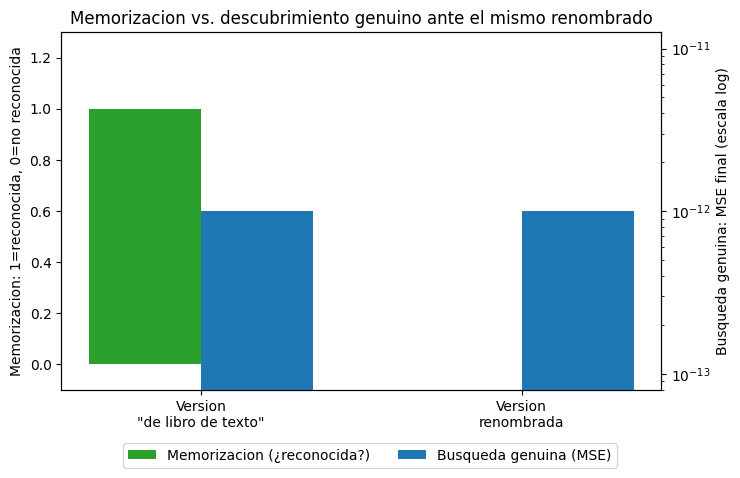

Resumen:
  Memorizacion:        libro de texto=OK   renombrada=FALLO
  Busqueda genuina:    libro de texto MSE=0.00e+00   renombrada MSE=0.00e+00  (sin diferencia)


In [5]:
fig, ax = plt.subplots(figsize=(7.5, 4.5))
labels = ['Version\n"de libro de texto"', 'Version\nrenombrada']
mem_results = [1, 0]  # 1=reconocida, 0=no reconocida
gp_results = [err_textbook, err_renamed]

x_pos = np.arange(2)
w = 0.35
ax2 = ax.twinx()
ax.bar(x_pos - w/2, mem_results, width=w, color=['tab:green', 'tab:red'], label='Memorizacion (¿reconocida?)')
ax2.bar(x_pos + w/2, [max(g, 1e-12) for g in gp_results], width=w, color='tab:blue', label='Busqueda genuina (MSE)')
ax2.set_yscale('log')
ax.set_xticks(x_pos); ax.set_xticklabels(labels)
ax.set_ylabel('Memorizacion: 1=reconocida, 0=no reconocida')
ax2.set_ylabel('Busqueda genuina: MSE final (escala log)')
ax.set_ylim(-0.1, 1.3)
ax.set_title('Memorizacion vs. descubrimiento genuino ante el mismo renombrado')
fig.legend(loc='upper center', bbox_to_anchor=(0.5, 0.02), ncol=2)
plt.tight_layout()
plt.show()

print('Resumen:')
print(f'  Memorizacion:        libro de texto={"OK" if mem_results[0] else "FALLO"}   renombrada={"OK" if mem_results[1] else "FALLO"}')
print(f'  Busqueda genuina:    libro de texto MSE={err_textbook:.2e}   renombrada MSE={err_renamed:.2e}  (sin diferencia)')

### Nota honesta sobre los resultados

- **No usamos LLMs reales.** Esta es la simplificacion mas importante: el paper evalua modelos de lenguaje reales (GPT-4, Claude, Llama, etc.) sobre 239 problemas en cuatro dominios cientificos, midiendo su tasa de precision simbolica bajo reformulaciones reales. Aqui construimos un **solucionador de memorizacion deliberadamente simplista** (una tabla de consulta por nombre de variable) como sustituto ilustrativo y extremo del atajo de reconocimiento textual que un LLM real podria tomar de forma mucho mas sutil -- un LLM real no falla de forma tan absoluta como nuestra tabla de consulta (podria reconocer parcialmente la estructura pese al renombrado), pero el paper documenta empiricamente que su precision **cae de forma sustancial** ante reformulaciones, incluso si no llega a cero.
- **Un unico tipo de reformulacion (renombrado de variables).** El paper tambien reformula ecuaciones reescribiendolas algebraicamente (p. ej. despejando una variable distinta) y introduciendo problemas sinteticos completamente nuevos sin nombre "famoso" alguno; aqui solo probamos el renombrado, el caso mas simple y directo de demostrar.
- **Solucionador de memorizacion como caricatura deliberada.** Nuestra tabla de consulta es un caso extremo (todo o nada) para que el fenomeno sea inequivoco de ver; el paper mide esta brecha de forma gradual y estadistica sobre muchos LLM y problemas, no con un solucionador binario como el nuestro.

Pese a estas simplificaciones, el cuaderno ilustra con claridad el problema metodologico central que motiva a LLM-SRBench: un sistema que dependa, aunque sea parcialmente, de reconocer patrones textuales familiares puede parecer mucho mas capaz de lo que realmente es en un benchmark con formulas "famosas" sin reformular -- mientras que un metodo de busqueda genuinamente guiado por los datos numericos es, por construccion, invariante a como se llamen las variables.